## Variable Selection for h5 files

### *–––– Set up ––––*

In [1]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json
import pandas as pd

NanoAODSchema.warn_missing_crossrefs = False

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [2]:
with open("samples.json", 'r') as sample_file:
    fileset = json.load(sample_file)

for sample in fileset:
    print(sample)

BulkGravToWW_1000
BulkGravToWW_2000
RSGravToWW_1200
RSGravToWW_2000


In [3]:
test_dataset = 'BulkGravToWW_1000'
events = NanoEventsFactory.from_root(
    fileset[test_dataset]['files'],
    entry_stop = 10000,
    metadata = fileset[test_dataset]['metadata'],
    schemaclass = NanoAODSchema,
    delayed=False,
).events()
# events = NanoEventsFactory.from_root(
#     list(fileset['BulkGravToWW']['files'].keys()),
#     schemaclass=NanoAODSchema,
#     metadata=fileset['BulkGravToWW']['metadata'],
#     delayed=False
# ).events()

### *–––– STEP 1: Tight Lepton Selection ––––*

In [4]:
muons = events.Muon
electrons = events.Electron

# Muon Tight selection
muons_tight = muons[
    (muons.pt > 35) &
    (muons.eta < 2.4) &
    (muons.tightId) &
    (
        ((muons.pt < 10) & (muons.dxy < 0.01)) |
        ((muons.pt >= 10) & (muons.dxy < 0.02))
    ) &
    (muons.dz < 0.05) &
    # particle flow isolated: tight or greater
    (muons.pfIsoId >= 4)
]

print(f"{len(ak.flatten(muons_tight))} out of {len(ak.flatten(muons))} muons pass the tight selection")

# Electron Tight selection

electrons_tight = electrons[
    (electrons.pt > 30) &
    (electrons.eta < 2.4) &  # barrel + endcap
    # (electrons.mvaFall17V2Iso_WP90 == True) &
    (
        ((electrons.pt < 15) & (electrons.dxy < 0.01)) |
        ((electrons.pt >= 15) & (electrons.dxy < 0.02))
    ) &
    # (electrons.cutBased >= 1) &      # tight cut-based ID
    (electrons.dxy < 0.05) & # dxy tighter
    (electrons.dz < 0.05) &
    (electrons.pfRelIso03_all < 0.15) &  # isolated
    (electrons.lostHits <= 1) &
    (electrons.convVeto == True)
]

print(f"{ len(ak.flatten(electrons_tight))} out of {len(ak.flatten(electrons))} electrons pass the tight selection")

2294 out of 6848 muons pass the tight selection
2350 out of 8876 electrons pass the tight selection


In [6]:
# muons.fields
# electrons.fields

In [5]:
# Count of tight leptons
tight_muon_count = ak.num(muons_tight)
tight_electron_count = ak.num(electrons_tight)

# --- Loose leptons for vetoing ---
loose_muons = muons[muons.looseId]
# loose_muons = muons[(muons.isPFcand) & (muons.mediumId) & (muons.pfRelIso03_all < 0.4)]
loose_muons = loose_muons[loose_muons.pt > 10]

loose_electrons = electrons[electrons.cutBased >= 2]
loose_electrons = loose_electrons[loose_electrons.pt > 10]

# Count of loose leptons
loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)

# --- Event selection mask: exactly one tight lepton and no extra loose leptons ---
single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)

# Apply mask to get final event selection
events_selected = events[single_lepton_mask]

print(f"{len(events_selected)} events {len(events)} passed the tight lepton selection and loose veto.")

3238 events 10000 passed the tight lepton selection and loose veto.


In [6]:
# Masks for exactly one tight lepton
one_tight_electron_mask = (tight_electron_count == 1) & (tight_muon_count == 0) & (loose_lepton_count == 1)
one_tight_muon_mask = (tight_muon_count == 1) & (tight_electron_count == 0) & (loose_lepton_count == 1)

# Apply masks to original tight collections
tight_electron_one = electrons_tight[one_tight_electron_mask]
tight_muon_one = muons_tight[one_tight_muon_mask]

#### *–––– Step 1: the plots ––––* 

In [9]:
# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(muons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(muons_tight.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Muon: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [10]:
# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(electrons.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ before tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# plt.hist(ak.to_numpy(ak.flatten(electrons_tight.pt)), bins=50, range=(0, 500), histtype='step')
# plt.xlabel(r"$p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Electron: $p_T$ after tight selection")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [11]:
# plt.figure(figsize=(12, 5))

# # --- Electrons ---
# plt.subplot(1, 2, 1)
# plt.hist(ak.to_numpy(ak.flatten(tight_electron_one.pt)), bins=30, range=(0, 300), histtype='step', color='orange')
# plt.xlabel(r"Tight Electron $p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Events with Exactly One Tight Electron")
# plt.grid(True)

# # --- Muons ---
# plt.subplot(1, 2, 2)
# plt.hist(ak.to_numpy(ak.flatten(tight_muon_one.pt)), bins=30, range=(0, 300), histtype='step', color='green')
# plt.xlabel(r"Tight Muon $p_T$ [GeV]")
# plt.ylabel("Counts")
# plt.title("Events with Exactly One Tight Muon")
# plt.grid(True)

# plt.tight_layout()
# plt.show()

### *–––– STEP 2: AK8 Cleaning ––––*

In [22]:
# FatJets cuts
clean_fatJets = events.FatJet[(events.FatJet.pt > 150) & (events.FatJet.eta < 2.4) & (events.FatJet.msoftdrop > 10)]

#Jets cuts
clean_Jets = events.Jet[(events.Jet.pt > 30) & (events.Jet.eta < 4.6)]

In [23]:
#Removing AK4(Jet) jets overlapping with AK8(FatJets) jets

#1: Form all possible Jet–FatJet pairs per event
jets_fatjets = ak.cartesian({"x": clean_Jets, "y": clean_fatJets})
#2: Compute ΔR² separation between each Jet–FatJet pair
jets_iso_f = ((jets_fatjets["x"].eta-jets_fatjets["y"].eta)**2+(jets_fatjets["x"].phi-jets_fatjets["y"].phi)**2>0.8**2)
#3: Mask out jets with ΔR < 0.8 (i.e. remove overlapping jets)
jets_fatjets = jets_fatjets[jets_iso_f]
#4 Separate pairs into jets and fatjets, redefining the jets (but not the fatjets) 
jets, fj = ak.unzip(jets_fatjets)

In [24]:
# Require events with at least 1 clean AK8 FatJets
AK8jets_candidates_mask = ak.num(clean_fatJets) >= 1
Wjets_candidates = clean_fatJets[AK8jets_candidates_mask]

leading_W_jet = Wjets_candidates[:, 0]
leading_W_jet_pt = leading_W_jet.pt

In [25]:
# Require events with at least  clean AK8 FatJets
AK8jets_2_mask = ak.num(clean_fatJets) >= 2
Wjets_2_candidates = clean_fatJets[AK8jets_2_mask]

second_W_jet = Wjets_2_candidates[:, 1]
second_W_jet_pt = second_W_jet.pt

#### Step 2: plots

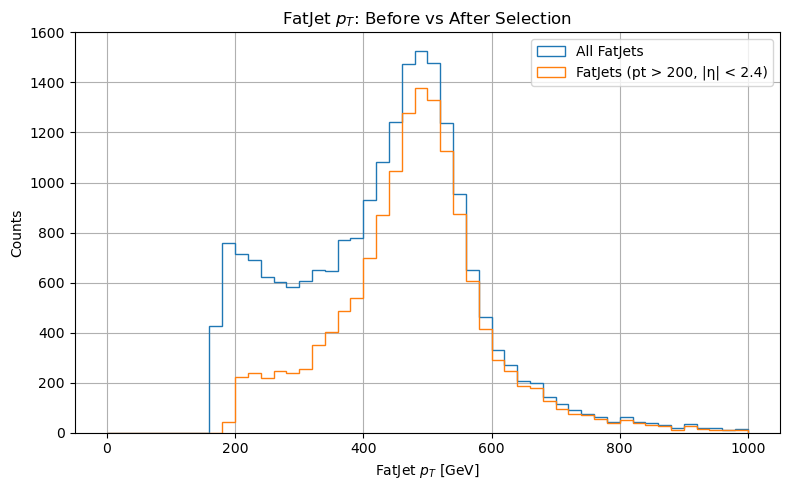

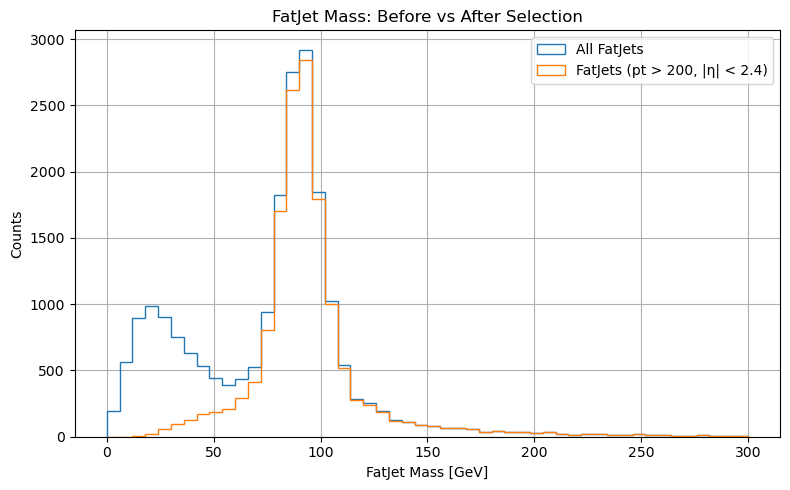

In [63]:
## FatJets before and after
# --- FatJet pT ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.pt)), bins=50, range=(0, 1000),
         histtype='step', label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=50, range=(0, 1000),
         histtype='step', label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("FatJet $p_T$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- FatJet mass ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.FatJet.mass)), bins=50, range=(0, 300),
         histtype='step', label='All FatJets')
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.mass)), bins=50, range=(0, 300),
         histtype='step', label='FatJets (pt > 200, |η| < 2.4)')
plt.xlabel(r"FatJet Mass [GeV]")
plt.ylabel("Counts")
plt.title("FatJet Mass: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2065/709102650.py:24: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Jet $\eta$: Before vs After Selection")


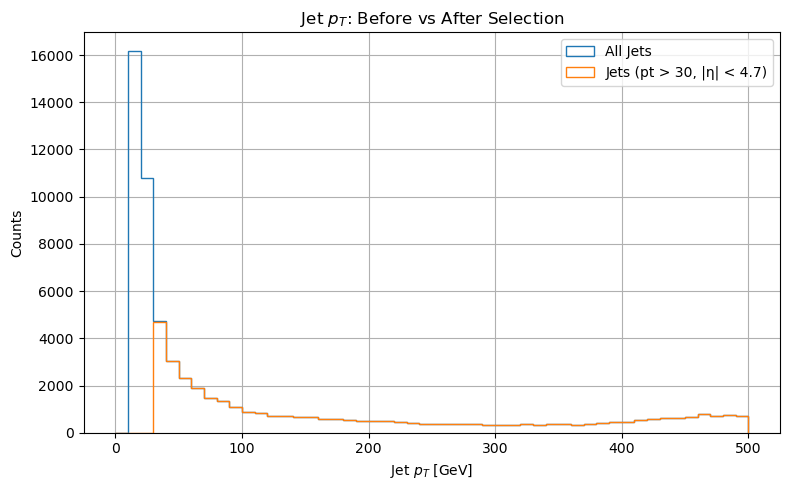

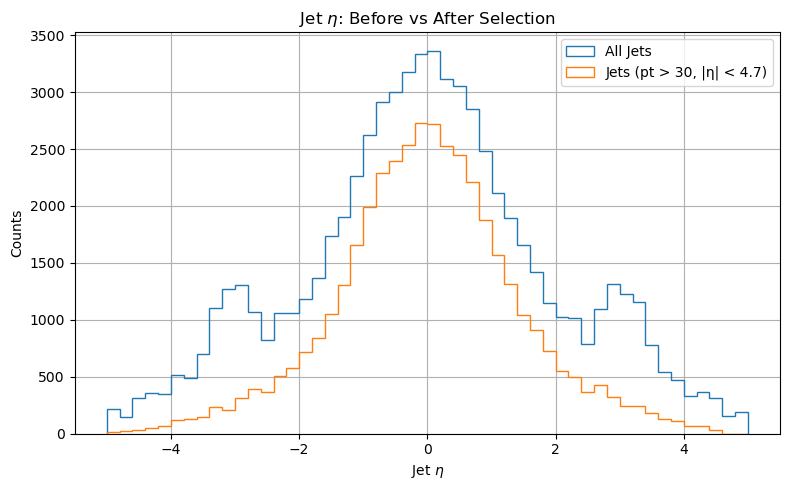

In [64]:
## Jets before and after 
# --- Jet pT ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.Jet.pt)), bins=50, range=(0, 500),
         histtype='step', label='All Jets')
plt.hist(ak.to_numpy(ak.flatten(clean_Jets.pt)), bins=50, range=(0, 500),
         histtype='step', label='Jets (pt > 30, |η| < 4.7)')
plt.xlabel(r"Jet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Jet $p_T$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Jet eta ---
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(events.Jet.eta)), bins=50, range=(-5, 5),
         histtype='step', label='All Jets')
plt.hist(ak.to_numpy(ak.flatten(clean_Jets.eta)), bins=50, range=(-5, 5),
         histtype='step', label='Jets (pt > 30, |η| < 4.7)')
plt.xlabel(r"Jet $\eta$")
plt.ylabel("Counts")
plt.title("Jet $\eta$: Before vs After Selection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

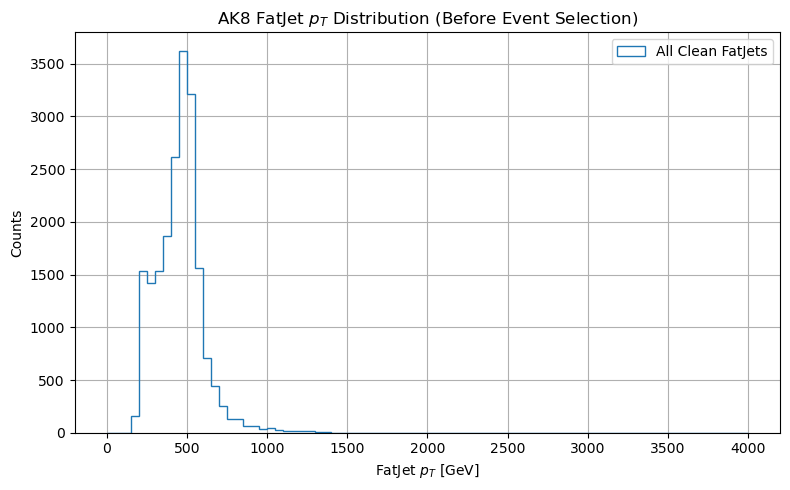

In [18]:
# Plot distribution of AK8 FatJets before applying AK8jets_candidates_mask
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(ak.flatten(clean_fatJets.pt)), bins=80, range=(0, 4000),
         histtype='step', label='All Clean FatJets')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("AK8 FatJet $p_T$ Distribution (Before Event Selection)")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

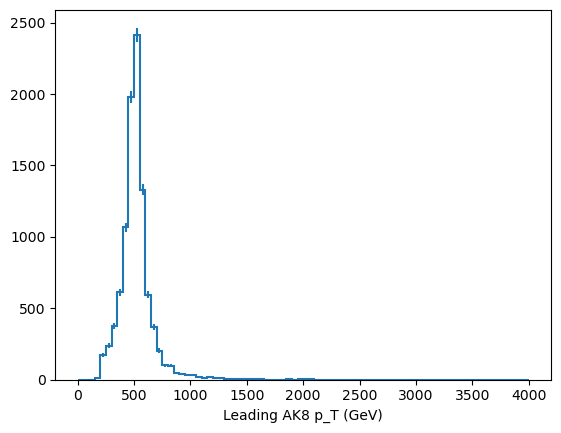

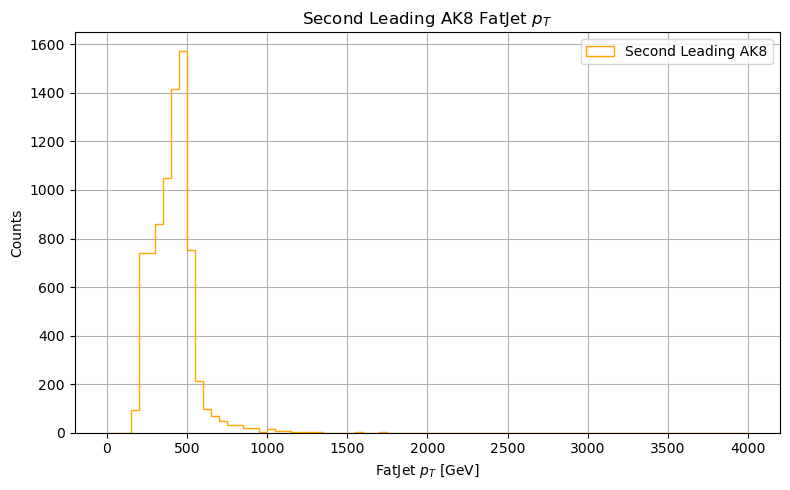

In [19]:
# Plot leading AK8 jet
leading_W_pt_hist = hist.Hist(hist.axis.StrCategory(name='dataset', label="Dataset", categories=[], growth=True),
                            hist.axis.Regular(name='leading_AK8_pt', label='Leading AK8 p_T (GeV)', bins=80, start=0, stop=4000))
leading_W_pt_hist.fill(dataset=test_dataset, leading_AK8_pt=leading_W_jet_pt)
leading_W_pt_hist.plot1d()

# Plot second-leading AK8 jet
plt.figure(figsize=(8, 5))
plt.hist(ak.to_numpy(second_W_jet_pt), bins=80, range=(0, 4000),
         histtype='step', color='orange', label='Second Leading AK8')
plt.xlabel(r"FatJet $p_T$ [GeV]")
plt.ylabel("Counts")
plt.title("Second Leading AK8 FatJet $p_T$")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

### *––––STEP 3: Event Catagorization: Define Semi-Leptonic and Hadronic Categories Using AK8 Jets ––––*

In [26]:
#tight lepton masks (already defined these earlier in the notebook)
n_tight_muons = ak.num(muons_tight)
n_tight_electrons = ak.num(electrons_tight)

# event masks
semi_leptonic_mask = (
    ((n_tight_muons == 1) & (n_tight_electrons == 0)) |
    ((n_tight_muons == 0) & (n_tight_electrons == 1))) & (ak.num(clean_fatJets) >= 1)

fully_hadronic_mask = (
    (n_tight_muons == 0) & (n_tight_electrons == 0) &
    (ak.num(clean_fatJets) >= 2))

In [27]:
# semi-leptonic W decay: 
semi_leptonic_fatjets = clean_fatJets[semi_leptonic_mask]
# fully hadronic W decay: 
fully_hadronic_fatjets = clean_fatJets[fully_hadronic_mask]

In [28]:
# For plotting (flatten to leading/subleading jets)
semi_leptonic_leading_jet = semi_leptonic_fatjets[:, 0]
fully_hadronic_leading_jet = fully_hadronic_fatjets[:, 0]

print(f" Semi-Leptonic Jet count: {len(semi_leptonic_leading_jet)} & Hadronic Jet Count: {len(fully_hadronic_leading_jet)}.")
# assumes there are at least two AK8 jets in the event
fully_hadronic_second_jet = fully_hadronic_fatjets[:, 1]

 Semi-Leptonic Jet count: 3132 & Hadronic Jet Count: 4343.


### *––––STEP 4: Calculate and Plot relevant variables––––*

#### kinematic variables

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2428/3244766382.py:4: SyntaxWarning: invalid escape sequence '\e'
  "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),


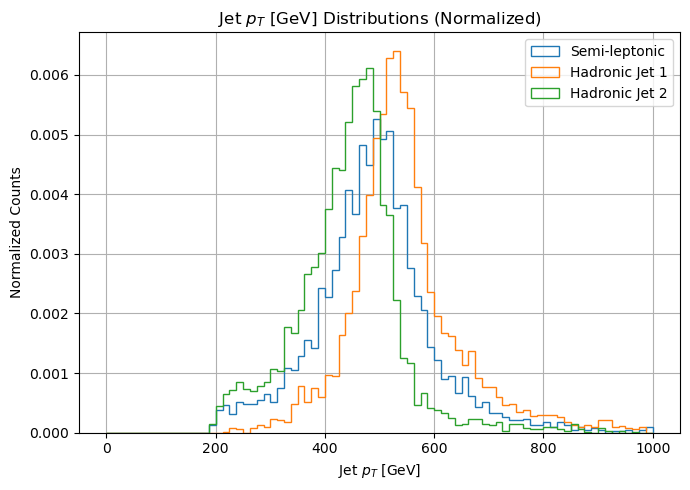

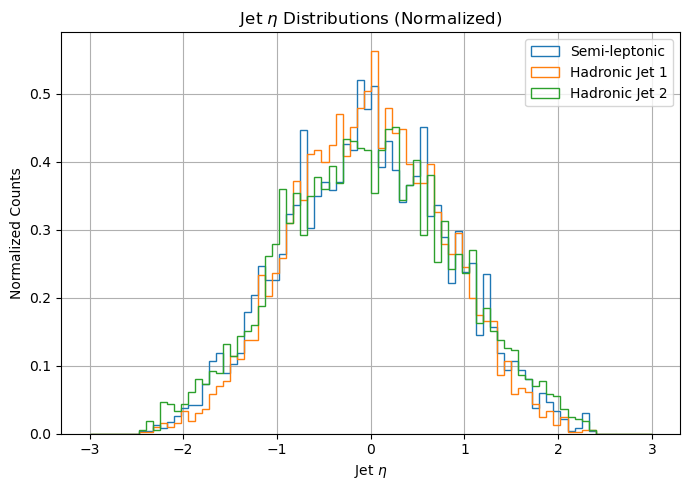

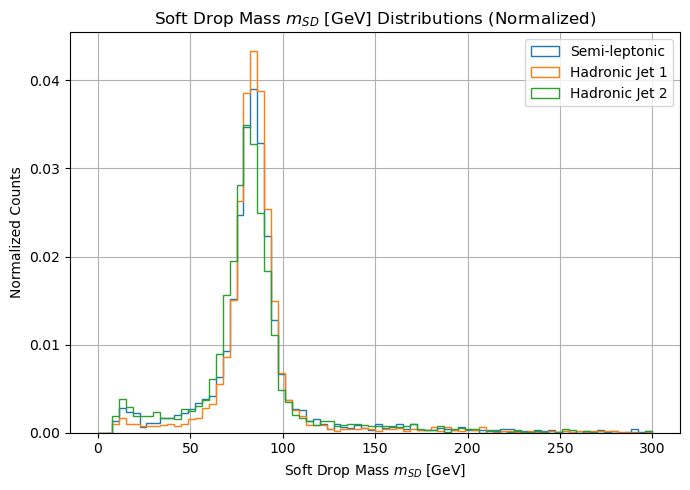

In [29]:
# dict mapping jet properties to axis labels, plot ranges, and access functions
jet_sets = {
    "pt": ("Jet $p_T$ [GeV]", (0, 1000), lambda jet: jet.pt),
    "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),
    "msoftdrop": ("Soft Drop Mass $m_{SD}$ [GeV]", (0, 300), lambda jet: jet.msoftdrop)
}
# loop over each jet parameter to generate plots
for key, (xlabel, rng, accessor) in jet_sets.items():
    plt.figure(figsize=(7, 5))
    
    # # left: non-normalized
    # plt.subplot(1, 2, 1)
    # plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=60, range=rng,
    #          histtype='step', label='Semi-leptonic')
    # plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=80, range=rng,
    #          histtype='step', label='Hadronic Jet 1')
    # plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=80, range=rng,
    #          histtype='step', label='Hadronic Jet 2')
    # plt.title(f"{xlabel} Distributions (Non-Normalized)")
    # plt.xlabel(xlabel)
    # plt.ylabel("Counts")
    # plt.legend()
    # plt.grid(True)

    # right: normalized
    plt.subplot(1, 1, 1)
    plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Semi-leptonic')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Hadronic Jet 1')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Hadronic Jet 2')
    plt.title(f"{xlabel} Distributions (Normalized)")
    plt.xlabel(xlabel)
    plt.ylabel("Normalized Counts")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#### sub-jet features

In [30]:
# -- Subjet Pair Extraction for Semi-Leptonic Events --
def extract_semi_subjet_pairs(fatjets, all_subjets, category_name="Semi-Leptonic"):
    pairs = []
    n_skipped = 0

    for event_fjs, event_sjs in zip(fatjets, all_subjets):
        if len(event_fjs) == 0:
            continue
        fj = event_fjs[0]
        try:
            idx1, idx2 = fj.subJetIdx1, fj.subJetIdx2
            if idx1 < 0 or idx2 < 0:
                raise ValueError("Invalid subjet indices")

            sj1, sj2 = event_sjs[idx1], event_sjs[idx2]
            vec1 = vector.obj(pt=sj1["pt"], eta=sj1["eta"], phi=sj1["phi"], mass=sj1["mass"])
            vec2 = vector.obj(pt=sj2["pt"], eta=sj2["eta"], phi=sj2["phi"], mass=sj2["mass"])
            pairs.append((vec1, vec2))
        except (KeyError, TypeError, ValueError):
            n_skipped += 1

    print(f"[{category_name}] Valid subjet pairs: {len(pairs)}, Skipped: {n_skipped}")
    return pairs

# -- Subjet Pair Extraction for Hadronic Events --
def extract_had_subjet_pairs(fatjets, category_name="Hadronic"):
    valid_pairs = []
    n_skipped = 0

    for subjets in fatjets.subjets:
        if len(subjets) < 2:
            n_skipped += 1
            continue
        try:
            sj1, sj2 = subjets[0], subjets[1]
            vec1 = vector.obj(pt=sj1["pt"], eta=sj1["eta"], phi=sj1["phi"], mass=sj1["mass"])
            vec2 = vector.obj(pt=sj2["pt"], eta=sj2["eta"], phi=sj2["phi"], mass=sj2["mass"])
            valid_pairs.append((vec1, vec2))
        except (KeyError, TypeError, ValueError):
            n_skipped += 1

    print(f"[{category_name}] Valid subjet pairs: {len(valid_pairs)}, Skipped: {n_skipped}")
    return valid_pairs

In [31]:
# -- Extract Pairs from Each Jet Category --
semi_pairs = extract_semi_subjet_pairs(semi_leptonic_fatjets, events.SubJet[semi_leptonic_mask], "Semi-Leptonic")
had1_pairs = extract_had_subjet_pairs(fully_hadronic_leading_jet, "Hadronic Lead")
had2_pairs = extract_had_subjet_pairs(fully_hadronic_second_jet, "Hadronic Sublead")

[Semi-Leptonic] Valid subjet pairs: 3132, Skipped: 0
[Hadronic Lead] Valid subjet pairs: 4343, Skipped: 0
[Hadronic Sublead] Valid subjet pairs: 4343, Skipped: 0


##### 4a——energy-correlation function

In [32]:
# -------------------------
# Helpers
# -------------------------
def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2*np.pi) - np.pi

def delta_r(eta1, phi1, eta2, phi2):
    return np.sqrt((eta1 - eta2)**2 + delta_phi(phi1, phi2)**2)

def _ecf2(parts, beta=1):
    """
    parts: awkward array [events, constituents] with fields pt, eta, phi
    returns: e2^{(beta)} per jet
    """
    pt_sum = ak.sum(parts.pt, axis=-1)
    comb2 = ak.combinations(parts, 2, fields=['a','b'])
    dr    = delta_r(comb2.a.eta, comb2.a.phi, comb2.b.eta, comb2.b.phi)
    num   = ak.sum(comb2.a.pt * comb2.b.pt * (dr**beta), axis=-1)
    return num / (pt_sum**2)

def _ecf3(parts, beta=1):
    """
    e3^{(beta)}. Will be 0 (or None) if fewer than 3 constituents.
    """
    pt_sum = ak.sum(parts.pt, axis=-1)
    comb3  = ak.combinations(parts, 3, fields=['a','b','c'])
    # pairwise ΔR products
    dr_ab = delta_r(comb3.a.eta, comb3.a.phi, comb3.b.eta, comb3.b.phi)
    dr_ac = delta_r(comb3.a.eta, comb3.a.phi, comb3.c.eta, comb3.c.phi)
    dr_bc = delta_r(comb3.b.eta, comb3.b.phi, comb3.c.eta, comb3.c.phi)
    prod_dr = (dr_ab * dr_ac * dr_bc)**beta
    num = ak.sum(comb3.a.pt * comb3.b.pt * comb3.c.pt * prod_dr, axis=-1)
    return num / (pt_sum**3)

def compute_ecfs(jets, use_constituents=True, beta=1):
    """
    jets: awkward array of AK8 jets
    If use_constituents is False, we'll use jets.subjets instead.
    Returns e2, e3, (optionally) C2 and D2 masks.
    """
    # pick constituents or fallback to subjets
    if use_constituents and hasattr(jets, "constituents"):
        parts = jets.constituents
    else:
        parts = jets.subjets

    # e2 (β=1) and e2 (β=2)
    e2_b1 = _ecf2(parts, beta=beta)
    e2_b2 = _ecf2(parts, beta=2)

    # e3 and ratios
    have3  = ak.num(parts) >= 3
    e3_raw = _ecf3(parts, beta=beta)
    e3     = ak.where(have3, e3_raw, 0.0)
    C2     = ak.where((e2_b1 > 0) & have3, e3 / (e2_b1**2), 0.0)
    D2     = ak.where((e2_b1 > 0) & have3, e3 / (e2_b1**3), 0.0)

    # pTD = sqrt(sum(pt^2)) / sum(pt)
    # two‑subjet kinematics:
    pt_sum  = ak.sum(parts.pt, axis=-1)
    pt2_sum = ak.sum(parts.pt**2, axis=-1)
    pTD     = ak.where(pt_sum > 0, (pt2_sum**0.5) / pt_sum, 0.0)

    have2 = ak.num(parts) >= 2
    pt1   = ak.where(have2, parts.pt[:, 0], 0.0)
    pt2   = ak.where(have2, parts.pt[:, 1], 0.0)

    # momentum sharing z = min(pt1,pt2)/(pt1+pt2)
    z = ak.where( have2,ak.where(pt1 < pt2, pt1, pt2) / pt_sum, 0.0)

    # ΔR between the two leading subjets
    dr12 = ak.where( have2, delta_r(parts.eta[:, 0], parts.phi[:, 0],
    parts.eta[:, 1], parts.phi[:, 1]), 0.0)
    return e2_b1, e2_b2, e3, C2, D2, pTD, z, dr12

<>:65: SyntaxWarning: invalid escape sequence '\!'
<>:65: SyntaxWarning: invalid escape sequence '\!'
/tmp/ipykernel_2428/426314132.py:65: SyntaxWarning: invalid escape sequence '\!'
  axs[1,1].set(title="z vs $p_{T\!D}$", xlabel="z", ylabel=r"$p_{T\!D}$")


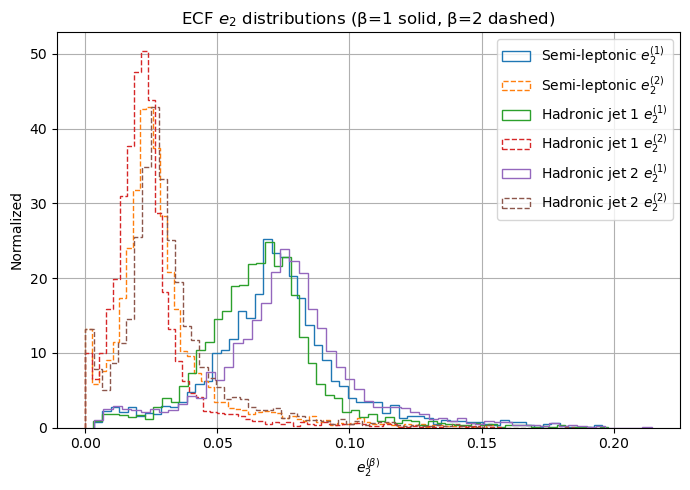

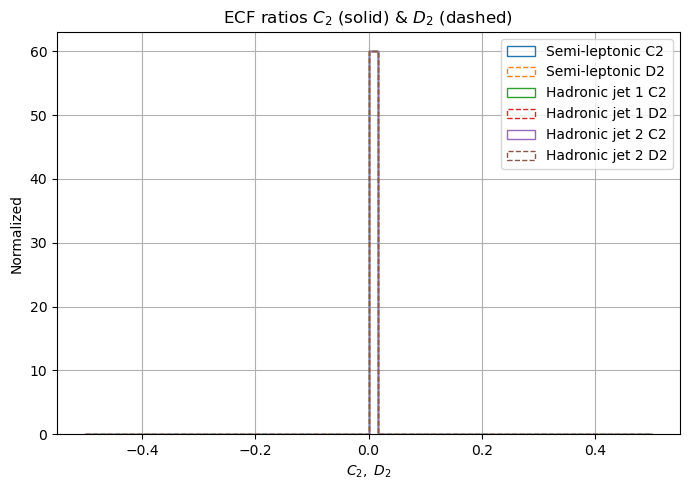

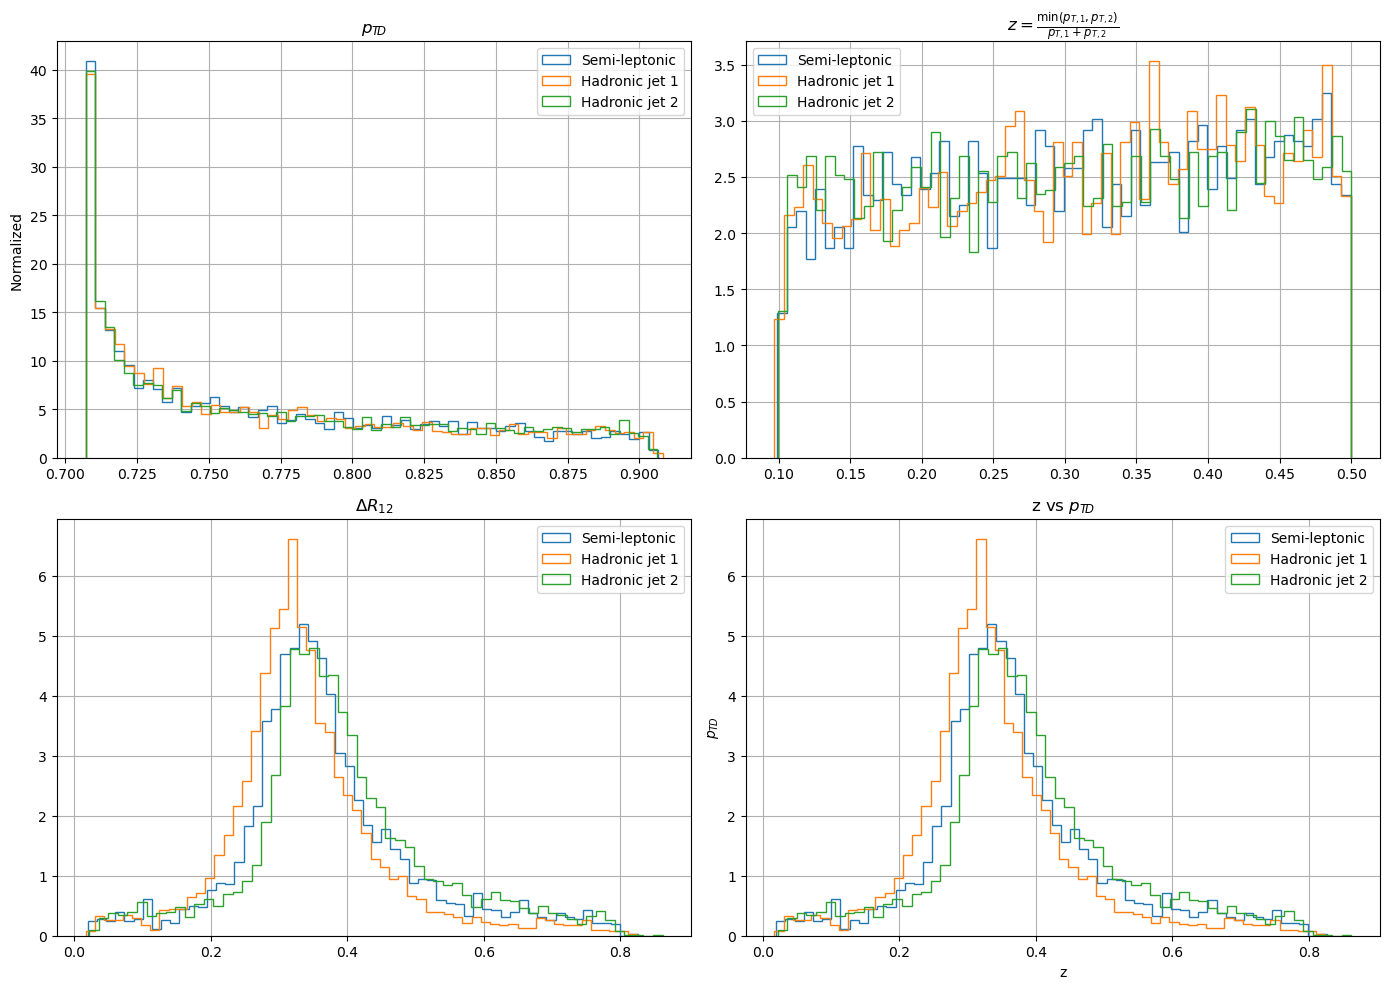

In [33]:
USE_CONSTITUENTS = False

# compute for each category
e2_1_s, e2_2_s, e3_s, C2_s, D2_s, pTD_s, z_s, dr12_s = compute_ecfs(
    semi_leptonic_leading_jet, USE_CONSTITUENTS, beta=1
)
e2_1_h1,e2_2_h1,e3_h1,C2_h1,D2_h1, pTD_h1, z_h1, dr12_h1 = compute_ecfs(
    fully_hadronic_leading_jet, USE_CONSTITUENTS, beta=1
)
e2_1_h2,e2_2_h2,e3_h2,C2_h2,D2_h2, pTD_h2, z_h2, dr12_h2 = compute_ecfs(
    fully_hadronic_second_jet, USE_CONSTITUENTS, beta=1
)

# helper to numpy‑ify
def to_np(x): 
    return ak.to_numpy(ak.fill_none(x, 0.0))

# ——— 1) ECF e2 (β=1,2) ———
plt.figure(figsize=(7,5))
plt.hist(to_np(e2_1_s), bins=60, density=True,   histtype='step', label=r'Semi-leptonic $e_2^{(1)}$')
plt.hist(to_np(e2_2_s), bins=60, density=True,   histtype='step', label=r'Semi-leptonic $e_2^{(2)}$', linestyle='--')
plt.hist(to_np(e2_1_h1),bins=60,density=True,   histtype='step', label=r'Hadronic jet 1 $e_2^{(1)}$')
plt.hist(to_np(e2_2_h1),bins=60,density=True,   histtype='step', label=r'Hadronic jet 1 $e_2^{(2)}$', linestyle='--')
plt.hist(to_np(e2_1_h2),bins=60,density=True,   histtype='step', label=r'Hadronic jet 2 $e_2^{(1)}$')
plt.hist(to_np(e2_2_h2),bins=60,density=True,   histtype='step', label=r'Hadronic jet 2 $e_2^{(2)}$', linestyle='--')
plt.xlabel(r"$e_2^{(\beta)}$")
plt.ylabel("Normalized")
plt.title("ECF $e_2$ distributions (β=1 solid, β=2 dashed)")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

# ——— 2) C2 & D2 ———
plt.figure(figsize=(7,5))
plt.hist(to_np(C2_s), bins=60, density=True, histtype='step', label='Semi-leptonic C2')
plt.hist(to_np(D2_s), bins=60, density=True, histtype='step', label='Semi-leptonic D2', linestyle='--')
plt.hist(to_np(C2_h1),bins=60, density=True, histtype='step', label='Hadronic jet 1 C2')
plt.hist(to_np(D2_h1),bins=60, density=True, histtype='step', label='Hadronic jet 1 D2', linestyle='--')
plt.hist(to_np(C2_h2),bins=60, density=True, histtype='step', label='Hadronic jet 2 C2')
plt.hist(to_np(D2_h2),bins=60, density=True, histtype='step', label='Hadronic jet 2 D2', linestyle='--')
plt.xlabel(r"$C_2,\ D_2$")
plt.ylabel("Normalized")
plt.title("ECF ratios $C_2$ (solid) & $D_2$ (dashed)")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

# ——— 3) new two‑subjet features ———
fig, axs = plt.subplots(2,2,figsize=(14,10))

axs[0,0].hist(to_np(pTD_s), bins=60, density=True, histtype='step', label='Semi-leptonic')
axs[0,0].hist(to_np(pTD_h1),bins=60, density=True, histtype='step', label='Hadronic jet 1')
axs[0,0].hist(to_np(pTD_h2),bins=60, density=True, histtype='step', label='Hadronic jet 2')
axs[0,0].set(title=r"$p_{T\!D}$", xlabel="", ylabel="Normalized")

axs[0,1].hist(to_np(z_s), bins=60, density=True, histtype='step', label='Semi-leptonic')
axs[0,1].hist(to_np(z_h1),bins=60, density=True, histtype='step', label='Hadronic jet 1')
axs[0,1].hist(to_np(z_h2),bins=60, density=True, histtype='step', label='Hadronic jet 2')
axs[0,1].set(title=r"$z=\frac{\min(p_{T,1},p_{T,2})}{p_{T,1}+p_{T,2}}$", xlabel="", ylabel="")

axs[1,0].hist(to_np(dr12_s), bins=60, density=True, histtype='step', label='Semi-leptonic')
axs[1,0].hist(to_np(dr12_h1),bins=60, density=True, histtype='step', label='Hadronic jet 1')
axs[1,0].hist(to_np(dr12_h2),bins=60, density=True, histtype='step', label='Hadronic jet 2')
axs[1,0].set(title=r"$\Delta R_{12}$", xlabel="", ylabel="")

axs[1,1].hist(to_np(dr12_s), bins=60, density=True, histtype='step', label='Semi-leptonic')
axs[1,1].hist(to_np(dr12_h1),bins=60, density=True, histtype='step', label='Hadronic jet 1')
axs[1,1].hist(to_np(dr12_h2),bins=60, density=True, histtype='step', label='Hadronic jet 2')
axs[1,1].set(title="z vs $p_{T\!D}$", xlabel="z", ylabel=r"$p_{T\!D}$")

for ax in axs.flatten():
    ax.legend(); ax.grid()
plt.tight_layout(); plt.show()

##### cos$\theta$ * calculation and plotting

In [34]:
# -- Compute cos(θ*) for Given Subjet Pairs --
def compute_cos_theta_star_from_vectors(subjet_pairs, category_name=""):
    cos_theta_star = []
    n_success = 0
    n_skipped = 0

    for i, (vec1, vec2) in enumerate(subjet_pairs):
        # 1) Reconstruct the W four-vector in the lab frame
        w_lab = vec1 + vec2
        if w_lab.mass < 1e-3 or w_lab.E <= 1e-6:
            n_skipped += 1

        # 2) Build the boost to the W rest frame
        beta3 = -w_lab.to_beta3()
        if beta3.mag < 1e-6:
            n_skipped += 1
            continue
        
        # 3) RAPIDITY SORT: pick the subjet that’s more “backward” in η
        #    (this ensures the dot can go negative when it should)
        if vec1.rapidity < vec2.rapidity:
            q = vec1  
        else:
            q = vec2

        # 4) Boost that chosen subjet into the W rest frame
        q_rest = q.boost_beta3(beta3)
        if q_rest.to_beta3().mag < 1e-6:
            n_skipped += 1
            continue

        # 5) Compute signed cosθ* via vector’s unit-vector dot        
        w_hat  = w_lab.to_beta3().unit()
        q_hat  = q_rest.to_beta3().unit()
        cos_theta = q_hat.dot(w_hat)

        cos_theta_star.append(cos_theta)
        n_success += 1

    if len(cos_theta_star) > 0:
            cos_array = np.array(cos_theta_star)
            print(f"[{category_name}] Computed cosθ* for {n_success} subjet pairs, Skipped: {n_skipped}")
            print(f"[{category_name}] range: min = {cos_array.min():.3f}, max = {cos_array.max():.3f}")
            print(f"[{category_name}] Histogram counts (neg, zero, pos): "
                  f"{np.sum(cos_array < 0)}, {np.sum(cos_array == 0)}, {np.sum(cos_array > 0)}")
    return np.array(cos_theta_star)

In [35]:
# -- Compute cos(θ*) for Each Category --
cos_theta_semi = compute_cos_theta_star_from_vectors(semi_pairs, "Semi-Leptonic")
cos_theta_had1 = compute_cos_theta_star_from_vectors(had1_pairs, "Hadronic Lead")
cos_theta_had2 = compute_cos_theta_star_from_vectors(had2_pairs, "Hadronic Sublead")

[Semi-Leptonic] Computed cosθ* for 3132 subjet pairs, Skipped: 0
[Semi-Leptonic] range: min = -0.849, max = 0.855
[Semi-Leptonic] Histogram counts (neg, zero, pos): 1537, 0, 1595
[Hadronic Lead] Computed cosθ* for 4343 subjet pairs, Skipped: 0
[Hadronic Lead] range: min = -0.865, max = 0.865
[Hadronic Lead] Histogram counts (neg, zero, pos): 2121, 0, 2222
[Hadronic Sublead] Computed cosθ* for 4343 subjet pairs, Skipped: 0
[Hadronic Sublead] range: min = -0.853, max = 0.837
[Hadronic Sublead] Histogram counts (neg, zero, pos): 2187, 0, 2156


In [ ]:
# -- Plot Normalized cos(θ*) Distributions --
plt.figure(figsize=(7, 5))
plt.hist(cos_theta_semi, bins=60, range=(-1, 1), density=True,
         histtype='step', label='Semi-Leptonic Jet')
plt.hist(cos_theta_had1, bins=60, range=(-1, 1), density=True,
         histtype='step', label='Hadronic Jet 1')
plt.hist(cos_theta_had2, bins=60, range=(-1, 1), density=True,
         histtype='step', label='Hadronic Jet 2')
plt.xlabel(r"$\cos\theta^*$")
plt.ylabel("Normalized Count")
plt.title(r"Normalized $\cos\theta^*$ Distributions")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()